# Lab 2 explained simply: "Is this room comfortable?"

*(Easy version of `lab-2.ipynb`. Same program, same numbers, simpler words.)*

## The big idea

Your body is like a **little campfire**. All day and all night it makes heat, even when you sleep. The room around you is always **taking heat away**: through the air, the walls, the wind and your breath.

- If the room takes away **exactly as much heat as you make** → you feel **just right**.
- If the room takes away **too little** → heat piles up inside you → you feel **hot**.
- If the room takes away **too much** → you lose heat too fast → you feel **cold**.

Think of a **bathtub**: the tap is the heat your body makes, the drains are the ways heat leaves. If the water level rises, you are too hot. If it sinks, you are too cold. Level steady = comfortable.

The lab asks us to build a calculator that tells us **how warm people will feel** in a room (that number is called **PMV**), and **how many people will complain** (that is **PPD**).

## Fancy words → simple words

| Fancy word | Simple meaning | Unit (what we count it in) |
|---|---|---|
| **Air temperature** ($t_a$) | How warm the air is. What a normal thermometer shows. | °C (degrees Celsius) |
| **Mean radiant temperature** ($t_{mr}$) | How warm the **walls, floor, ceiling and windows** are on average. Sitting near a hot oven or a cold window, you feel it even if the air is fine. "Radiant" means "glowing warmth that travels through the air", like the sun on your face. | °C |
| **Operative temperature** ($t_o$) | The **"feels-like" temperature of the room**. It mixes the air temperature and the wall temperature into one number. | °C |
| **Relative humidity** (RH) | How **wet or sticky** the air is, compared with the most water it could hold. 60 % means "holding 60 out of 100 possible spoonfuls". | % |
| **Air speed** ($v$) | How strong the **breeze** is around you. A fan makes it bigger. | m/s (metres per second) |
| **Clothing insulation** ($I_{clo}$) | How **thick and warm your clothes** are. | clo (1 clo = a thick winter suit; 0.5 = light summer clothes) |
| **Metabolism** | Your body's **engine**. It slowly "burns" food to make energy and heat, all the time. | - |
| **Metabolic rate** ($M_{met}$) | **How fast the engine runs.** Sitting still = slow. Running = fast. | met (1 met = sitting quietly) |
| **W/m²** (watts per square metre) | How much heat leaves **each square metre of skin**, like tiny light bulbs glowing on you. | W/m² |
| **Heat-loss paths** ($RL_1 ... RL_6$) | The **six drains** that carry heat away from your body. | W/m² |
| **Thermal load** ($L$) | The heat **left over** in your body: made minus lost. | W/m² |
| **PMV** | **Predicted Mean Vote**: the average vote a big group of people would give when asked "how warm do you feel?" (−3 cold … 0 just right … +3 hot). | no unit |
| **PPD** | **Predicted Percentage Dissatisfied**: out of 100 people, how many are **unhappy**. | % |
| **Iteration** | **Guess, check, improve the guess**, and repeat, like the hot/cold guessing game. | count |

Everything is "per square metre of skin" so it works for small and big people alike. An adult has about 1.8 m² of skin.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from calculate_pmv_ppd import calculate_pmv_ppd

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID, BAND = "#0b0b0b", "#52514e", "#e4e3df", "#ecebe7"
plt.rcParams.update({"axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold"})

HOT_DAY = dict(t_a=30, t_mr=30.5, v=0.15, rh=60, i_clo=0.5, m_met=1.2)   # the outdoor summer day from the lab
COZY    = dict(t_a=24.5, t_mr=25, v=0.15, rh=60, i_clo=0.5, m_met=1.2)   # the indoor room we found
*_, hot = calculate_pmv_ppd(**HOT_DAY, details=True)
*_, cozy = calculate_pmv_ppd(**COZY, details=True)

## 1. Your engine: metabolism and metabolic rate

**Metabolism** is your body burning food (the fuel) to keep you alive: heart beating, brain thinking, muscles moving. Burning makes **heat** as a by-product, just like a car engine gets warm.

**Metabolic rate** is how fast that engine is running. We measure it in **met**:

- **1 met** = sitting quietly. That is the "idle" speed of your engine. By definition, 1 met = **58.15 W/m²**.
- **1.2 met** = sitting and doing light desk work (this is our lab's person).
- More movement means a faster engine and more heat.

Multiply by your skin area (about 1.8 m²) and you get the heat of the whole body. Sitting quietly gives about 105 W, about **one bright light bulb**!

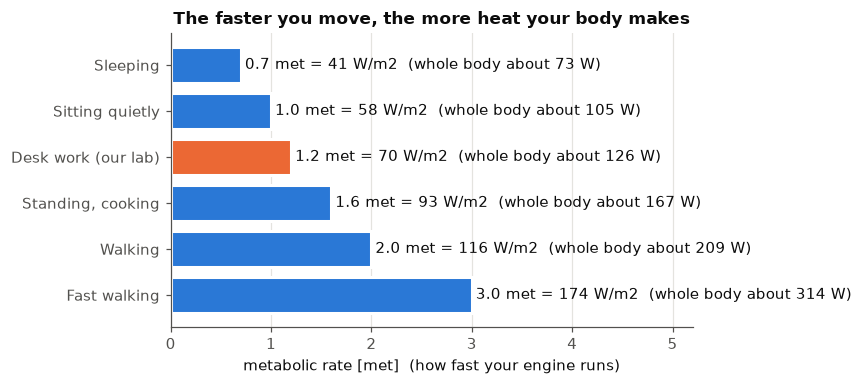

In [2]:
acts = {"Sleeping": 0.7, "Sitting quietly": 1.0, "Desk work (our lab)": 1.2, "Standing, cooking": 1.6,
        "Walking": 2.0, "Fast walking": 3.0}
names = list(acts); mets = list(acts.values())
fig, ax = plt.subplots(figsize=(7.5, 3.6))
cols = [ORANGE if n.startswith("Desk") else BLUE for n in names]
ax.barh(names, mets, color=cols, edgecolor="white", linewidth=2)
for i, m in enumerate(mets):
    ax.text(m + 0.04, i, f"{m} met = {m*58.15:.0f} W/m2  (whole body about {m*58.15*1.8:.0f} W)", va="center")
ax.invert_yaxis(); ax.set_xlim(0, 5.2); ax.set_xlabel("metabolic rate [met]  (how fast your engine runs)")
ax.grid(axis="y", visible=False); ax.set_title("The faster you move, the more heat your body makes")
plt.tight_layout(); plt.show()

**Reading it.** Longer bar = faster engine = more heat to get rid of. That is why you feel warm after running and cosy under a blanket while sleeping. The orange bar is the person in our lab (1.2 met = 69.8 W/m²).

## 2. Six drains: where does the heat go?

Your body keeps its inside at about 37 °C. The heat it makes has to leave through **six drains**:

| Drain | Simple words | What makes it bigger |
|---|---|---|
| $RL_1$ | water slowly **seeping through your skin** (you do not notice it) | dry air |
| $RL_2$ | **sweat** drying on your skin | working harder than sitting still |
| $RL_3$ | **wet breath**: water you breathe out | dry air, more activity |
| $RL_4$ | **warm breath**: you warm the air you breathe in | cold air |
| $RL_5$ | **radiation**: warmth glowing from your clothes to the walls | cold walls |
| $RL_6$ | **convection**: moving air carrying warmth away from your clothes | cold air, a breeze or fan |

**Left over** = heat made − heat lost through the six drains. We call it the **thermal load** ($L$).

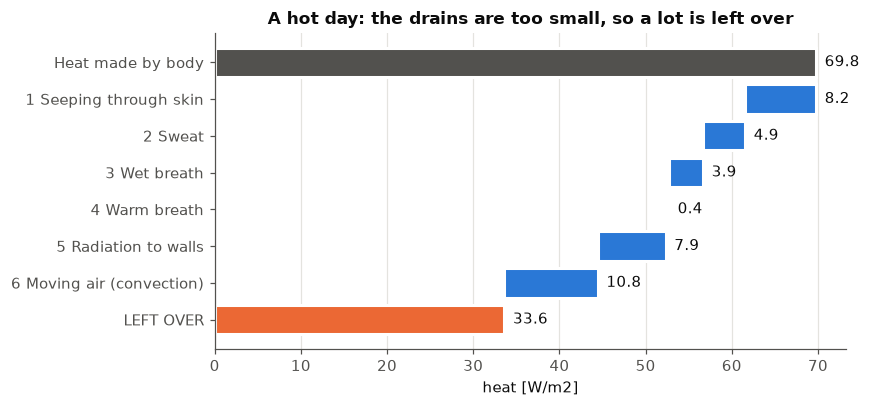

In [3]:
names = ["Heat made by body", "1 Seeping through skin", "2 Sweat", "3 Wet breath",
         "4 Warm breath", "5 Radiation to walls", "6 Moving air (convection)", "LEFT OVER"]
losses = [hot["RL1"], hot["RL2"], hot["RL3"], hot["RL4"], hot["RL5"], hot["RL6"]]
left, widths, colors = [0], [hot["M"]], [MUTED]
level = hot["M"]
for x in losses:
    level -= x
    left.append(level); widths.append(x); colors.append(BLUE)
left.append(0); widths.append(hot["L"]); colors.append(ORANGE)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(names, widths, left=left, color=colors, edgecolor="white", linewidth=2)
for i, (l, w) in enumerate(zip(left, widths)):
    ax.text(l + w + 1, i, f"{w:.1f}", va="center")
ax.invert_yaxis(); ax.set_xlabel("heat [W/m2]"); ax.grid(axis="y", visible=False)
ax.set_title("A hot day: the drains are too small, so a lot is left over")
plt.tight_layout(); plt.show()

**Reading it.** Start at the top (grey = heat made, 69.8). Each blue bar takes a bite out of it. The orange bar is what is **still inside you** (33.6): your body is piling up heat, so you feel hot.

## 3. Comfortable, cold and hot: made vs lost

Same person, three rooms. For each room, compare **heat made** (grey) with **heat lost** (blue). The gap is the bathtub level rising or sinking.

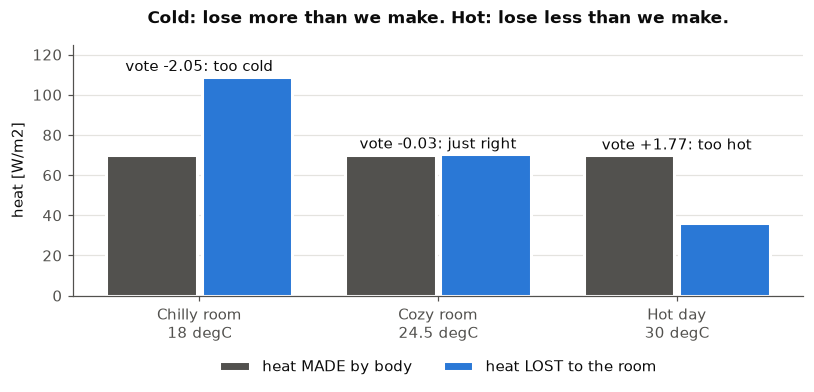

In [4]:
rooms = {"Chilly room\n18 degC": 18, "Cozy room\n24.5 degC": 24.5, "Hot day\n30 degC": 30}
made, lost, pmvs = [], [], []
for t in rooms.values():
    pmv, *_, dd = calculate_pmv_ppd(t, t + 0.5, details=True)
    made.append(dd["M"]); lost.append(dd["M"] - dd["L"]); pmvs.append(pmv)
x = np.arange(3)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(x - 0.2, made, 0.38, color=MUTED, edgecolor="white", linewidth=2, label="heat MADE by body")
ax.bar(x + 0.2, lost, 0.38, color=BLUE, edgecolor="white", linewidth=2, label="heat LOST to the room")
for i in range(3):
    word = "too cold" if pmvs[i] < -0.5 else "just right" if pmvs[i] < 0.5 else "too hot"
    ax.text(i, max(made[i], lost[i]) + 3, f"vote {pmvs[i]:+.2f}: {word}", ha="center", color=INK)
ax.set_xticks(x); ax.set_xticklabels(list(rooms)); ax.set_ylim(0, 125); ax.set_ylabel("heat [W/m2]")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2); ax.grid(axis="x", visible=False)
ax.set_title("Cold: lose more than we make. Hot: lose less than we make.", pad=14)
plt.tight_layout(); plt.show()

**Reading it.** In the cozy room the two bars are almost the same height, so the bathtub level stays steady. In the hot room the blue bar is too short. In the chilly room it is too tall.

## 4. The "feels-like" temperature: operative temperature

Imagine sitting in a room where the **air is a nice 24 °C**, but you are next to a **big cold window**. You still feel chilly, because your body sends its warmth *out to the cold window* (radiation). The thermometer only measures the air, so it misses this.

The **operative temperature** ($t_o$) fixes that. It is the room's **feels-like temperature**: a mix of air temperature and wall temperature.

$$t_o = A\cdot t_a + (1-A)\cdot t_{mr}$$

$A$ is how much the **air** counts. With a calm room (air speed under 0.2 m/s) the air and the walls count **equally**: $A = 0.5$. With more wind, the air counts more (0.6, then 0.7).

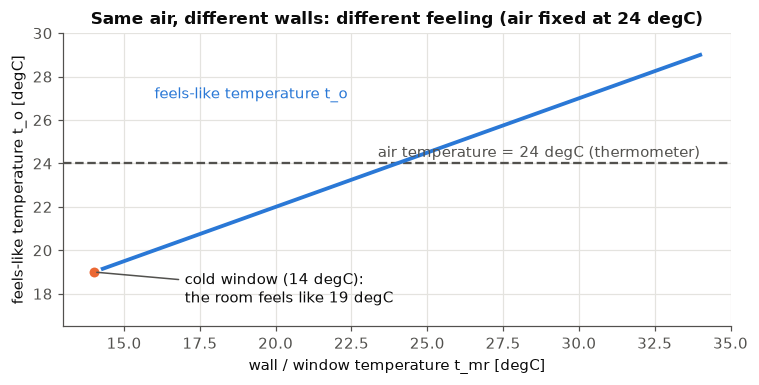

Lab day: air 30, walls 30.5  ->  feels like 30.25 degC


In [5]:
walls = np.linspace(14, 34, 50)
feels = 0.5 * 24 + 0.5 * walls                       # calm room: air and walls count equally (A = 0.5)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.axhline(24, color=MUTED, ls="--", lw=1.5)
ax.text(34, 24.3, "air temperature = 24 degC (thermometer)", ha="right", color=MUTED)
ax.plot(walls, feels, color=BLUE, lw=2.5)
ax.text(16, 27, "feels-like temperature t_o", color=BLUE)
ax.plot(14, 0.5*24 + 0.5*14, "o", color=ORANGE, ms=8, mec="white", mew=1.5)
ax.annotate("cold window (14 degC):\nthe room feels like 19 degC", (14, 19), xytext=(17, 17.6),
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_ylim(16.5, 30); ax.set_xlabel("wall / window temperature t_mr [degC]"); ax.set_ylabel("feels-like temperature t_o [degC]")
ax.set_title("Same air, different walls: different feeling (air fixed at 24 degC)")
plt.tight_layout(); plt.show()
print("Lab day: air 30, walls 30.5  ->  feels like", 0.5 * 30 + 0.5 * 30.5, "degC")

**Reading it.** The dashed line is what the thermometer says (always 24 °C). The blue line is what you feel. Cold walls drag the feeling down, warm walls push it up. In the lab, air = 30 °C and walls = 30.5 °C, so the room **feels like 30.25 °C**.

## 5. Humidity: sticky air

Air can carry **invisible water**. Warm air can carry **much more** than cold air. **Relative humidity** says how full the air is: 60 % means it holds 60 % of the water it could possibly hold.

When the air is already full of water, your **sweat cannot dry**, so you stay hot and sticky. Dry air takes sweat away easily and you feel cooler.

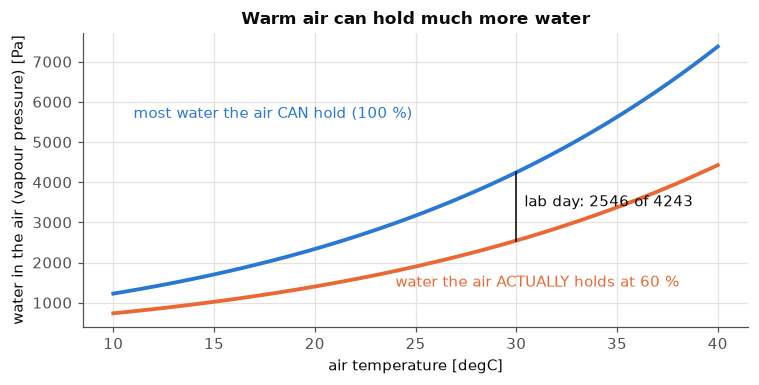

In [6]:
T = np.linspace(10, 40, 100)
p_max = np.exp(16.6536 - 4030.183 / (T + 235)) * 1000          # most water the air can hold [Pa] (Antoine equation)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(T, p_max, color=BLUE, lw=2.5); ax.plot(T, 0.6 * p_max, color=ORANGE, lw=2.5)
ax.text(11, 5600, "most water the air CAN hold (100 %)", color=BLUE)
ax.text(24, 1400, "water the air ACTUALLY holds at 60 %", color=ORANGE)
pm = np.exp(16.6536 - 4030.183 / 265) * 1000
ax.plot([30, 30], [0.6 * pm, pm], "k-", lw=1); ax.text(30.4, 3400, "lab day: 2546 of 4243", color=INK)
ax.set_xlabel("air temperature [degC]"); ax.set_ylabel("water in the air (vapour pressure) [Pa]")
ax.set_title("Warm air can hold much more water")
plt.tight_layout(); plt.show()

**Reading it.** The blue line goes up quickly: at 30 °C the air can hold 4243 "units" of water (Pa), at 10 °C only about 1228. At 60 % humidity our hot day has 2546 of them. In the program this number is called $p_v$ (partial vapour pressure).

## 6. Clothes and the surface-temperature guessing game

Clothes are a **blanket around you**. Their outside surface is cooler than your skin and warmer than the air. Its temperature, $t_{cl}$, decides how much heat leaves by radiation and moving air. But $t_{cl}$ depends on those same losses, so it is like a **chicken-and-egg** puzzle.

We solve it with a **guessing game** (an *iteration*):

1. Guess $t_{cl}$.
2. Use the guess to work out the heat leaving the clothes.
3. Use that to get a **better** $t_{cl}$.
4. Repeat until the new guess is **close enough** to the old one (less than $\epsilon$, a tiny number, in our case 0.0015).

Each round counts as **one iteration**. The lab says the hot day needs **8**.

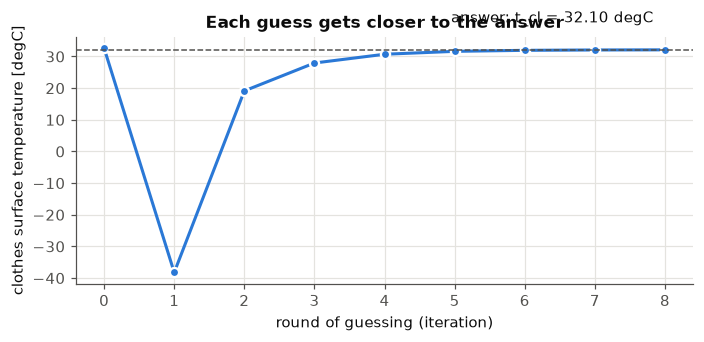

In [7]:
h = hot["history"]
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(range(len(h)), h, "-o", color=BLUE, lw=2, ms=6, mec="white", mew=1.5)
ax.axhline(h[-1], color=MUTED, lw=1, ls="--")
ax.annotate(f"answer: t_cl = {h[-1]:.2f} degC", (len(h) - 1, h[-1]), xytext=(-8, 18), textcoords="offset points", ha="right")
ax.set_xlabel("round of guessing (iteration)"); ax.set_ylabel("clothes surface temperature [degC]")
ax.set_title("Each guess gets closer to the answer")
plt.tight_layout(); plt.show()

**Reading it.** The first guess is a bit off. Every new guess lands closer to the dashed line, and after 8 rounds the guesses stop changing, so we stop.

## 7. From heat left over to a vote (PMV)

People do not feel "watts", they feel warm or cold. So we multiply the heat left over ($L$) by a **sensitivity number** ($TS$, "thermal sensation") that turns watts into a vote:

$$PMV = TS \times L$$

The vote scale goes from **−3 (cold)** to **+3 (hot)**. **0 means just right.** The lab says a room is **comfortable if PMV is between −0.5 and +0.5**.

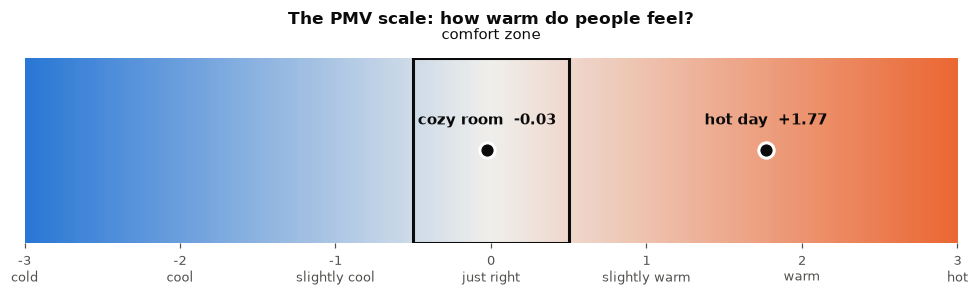

In [8]:
pmv_hot = calculate_pmv_ppd(**HOT_DAY)[0]; pmv_cozy = calculate_pmv_ppd(**COZY)[0]
cmap = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", ORANGE])
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.imshow(np.linspace(-3, 3, 300)[None, :], extent=(-3, 3, 0, 1), aspect="auto", cmap=cmap, vmin=-3, vmax=3)
ax.add_patch(plt.Rectangle((-0.5, 0), 1, 1, fill=False, ec=INK, lw=2))
ax.text(0, 1.08, "comfort zone", ha="center", va="bottom")
for xv, lab, dy in ((pmv_cozy, "cozy room", 0.5), (pmv_hot, "hot day", 0.5)):
    ax.plot(xv, 0.5, "o", color=INK, ms=10, mec="white", mew=2)
    ax.text(xv, 0.62, f"{lab}  {xv:+.2f}", ha="center", va="bottom", fontweight="bold")
words = ["cold", "cool", "slightly cool", "just right", "slightly warm", "warm", "hot"]
ax.set_xticks(range(-3, 4)); ax.set_xticklabels([f"{k}" + chr(10) + w for k, w in zip(range(-3, 4), words)], fontsize=8.5)
ax.set_yticks([]); ax.grid(False)
for s in ("left", "bottom"): ax.spines[s].set_visible(False)
ax.set_title("The PMV scale: how warm do people feel?", pad=22)
plt.tight_layout(); plt.show()

**Reading it.** Blue side = people feel cool. Orange side = people feel warm. The outlined box in the middle is the comfort zone. The hot day (+1.77) is between "warm" and "hot". The cozy room (about 0) is right in the middle.

## 8. Not everybody agrees: PPD

Even in a perfect room, people differ: one likes it warmer, one cooler. **PPD** tells us **out of 100 people, how many will complain**. Even at PMV = 0 about **5 out of 100** are still unhappy: you cannot please everyone!

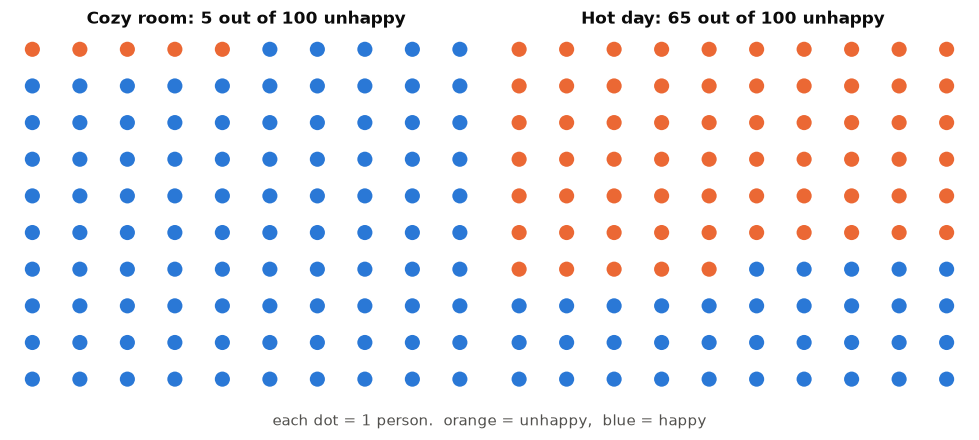

In [9]:
def dots(ax, ppd, title):
    n = int(round(ppd))
    xs, ys = np.meshgrid(np.arange(10), np.arange(10)[::-1])
    cols = [ORANGE if i < n else BLUE for i in range(100)]
    ax.scatter(xs.ravel(), ys.ravel(), c=cols, s=130, edgecolors="white", linewidths=1.5)
    ax.set_title(f"{title}: {n} out of 100 unhappy"); ax.axis("off")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
dots(axes[0], calculate_pmv_ppd(**COZY)[1], "Cozy room")
dots(axes[1], calculate_pmv_ppd(**HOT_DAY)[1], "Hot day")
fig.text(0.5, 0.02, "each dot = 1 person.  orange = unhappy,  blue = happy", ha="center", color=MUTED)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

**Reading it.** Left: our cozy indoor room, only 5 people complain. Right: the hot day, **65 out of 100** are unhappy.

## 9. What can we change to feel better? (the "levers")

On the hot day PMV is +1.77: too warm. Which small change cools the people down the most? The chart shows how much the **vote changes** for each change we make (negative = cooler = good here).

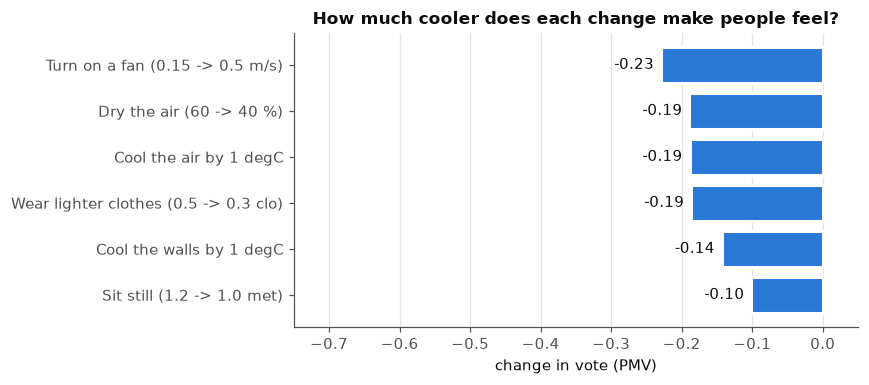

In [10]:
base = calculate_pmv_ppd(**HOT_DAY)[0]
changes = {
    "Cool the air by 1 degC":                   dict(t_a=HOT_DAY["t_a"] - 1),
    "Cool the walls by 1 degC":                 dict(t_mr=HOT_DAY["t_mr"] - 1),
    "Turn on a fan (0.15 -> 0.5 m/s)":          dict(v=0.5),
    "Wear lighter clothes (0.5 -> 0.3 clo)":    dict(i_clo=0.3),
    "Dry the air (60 -> 40 %)":                 dict(rh=40),
    "Sit still (1.2 -> 1.0 met)":               dict(m_met=1.0),
}
delta = {k: calculate_pmv_ppd(**{**HOT_DAY, **v})[0] - base for k, v in changes.items()}
order = sorted(delta, key=delta.get)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(order, [delta[k] for k in order], color=BLUE, edgecolor="white", linewidth=2)
for i, k in enumerate(order):
    ax.text(delta[k] - 0.01, i, f"{delta[k]:+.2f}", va="center", ha="right")
ax.invert_yaxis(); ax.set_xlim(-0.75, 0.05); ax.set_xlabel("change in vote (PMV)"); ax.grid(axis="y", visible=False)
ax.set_title("How much cooler does each change make people feel?")
plt.tight_layout(); plt.show()

**Reading it.** Each bar shows how far the vote drops for that one change. A fan helps most (−0.23), then drier air, 1 °C cooler air and lighter clothes (about −0.19 each). The hot day starts at +1.77 and we need to get under +0.5, so we need a drop of more than 1.27. Even a fan, lighter clothes, drier air and sitting still **all together** only reach about +0.74. So the real fix is to **cool the air** by several degrees: that is what air conditioning does.

## 10. The answer

| | Hot summer day (outside) | Our cozy room (inside) |
|---|---|---|
| Air temperature $t_a$ | 30 °C | **24.5 °C** |
| Wall temperature $t_{mr}$ | 30.5 °C | **25 °C** (summer rule: walls = air + 0.5) |
| Humidity, air speed, clothes, activity | 60 %, 0.15 m/s, 0.5 clo, 1.2 met | same |
| **PMV** (vote) | **1.767** (too hot) | **−0.027** (just right) |
| **PPD** (unhappy people) | **65.3 %** | **5.0 %** |
| **$t_o$** (feels-like) | **30.25 °C** | **24.75 °C** |
| **Iterations** (rounds of guessing) | **8** | **8** |

Any air temperature from about **23.25 °C to 26 °C** (walls = air + 0.5) keeps the vote between −0.5 and +0.5.

In [11]:
for name, case in (("Hot day", HOT_DAY), ("Cozy room", COZY)):
    pmv, ppd, t_o, n = calculate_pmv_ppd(**case)
    print(f"{name}:  PMV= {pmv:.3f}   PPD= {ppd:.1f} %   t_o= {t_o:.2f} degC   n iterations= {n}")

Hot day:  PMV= 1.767   PPD= 65.3 %   t_o= 30.25 degC   n iterations= 8
Cozy room:  PMV= -0.027   PPD= 5.0 %   t_o= 24.75 degC   n iterations= 8
